📦 데이터를 불러오는 중...
✅ 데이터 로드 완료! (Train: (299013, 310), Test: (686901, 310))
🖥️ 하드웨어 가속 상태: 🚀 GPU (사용 가능)


🚀 CV 진행률: 100%|██████████| 5/5 [00:16<00:00,  3.27s/it]



📊 [교차 검증] 평균 PR-AUC: 0.7552
🎯 [최종 테스트] PR-AUC: 0.4114

🏆 상위 10개 피처:
             feature    importance
       smart_197_raw 502398.161996
     s187_error_rate 132473.356278
       smart_184_raw  56183.794427
     s198_error_rate  36394.213137
total_seeks_28d_asfd  33880.058988
   error_density_14d  24461.077709
         smart_9_raw  19947.687601
       smart_242_raw  16919.763507
       smart_187_raw  15713.879865
  workload_intensity  15536.424163

📉 하위 10개 피처 (제거 후보):
                 feature  importance
pending_to_offline_ratio         0.0
  s5_daily_failure_speed         0.0
                 s5_diff         0.0
               s199_diff         0.0
               s189_diff         0.0
               s191_diff         0.0
         timeout_5s_diff         0.0
      timeout_total_diff         0.0
               s198_diff         0.0
   seek_error_count_diff         0.0


C:\Users\joon6\AppData\Local\Temp\ipykernel_1984\174567363.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
C:\Users\joon6\AppData\Local\Temp\ipykernel_1984\174567363.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
C:\Users\joon6\AppData\Local\Temp\ipykernel_1984\174567363.py:91: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\joon6\AppData\Local\Temp\ipykernel_1984\174567363.py:91: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) De

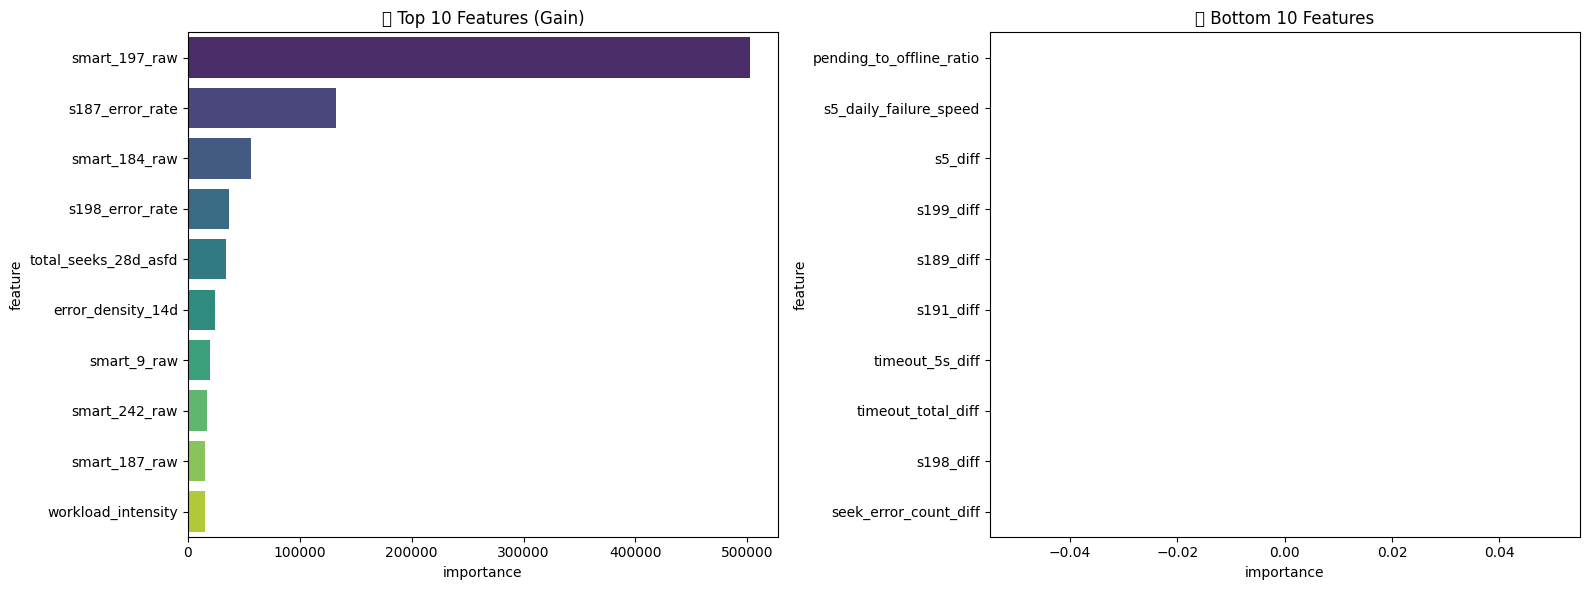


🔮 SHAP 분석 진행 중... (샘플링된 500개 데이터 분석)


c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


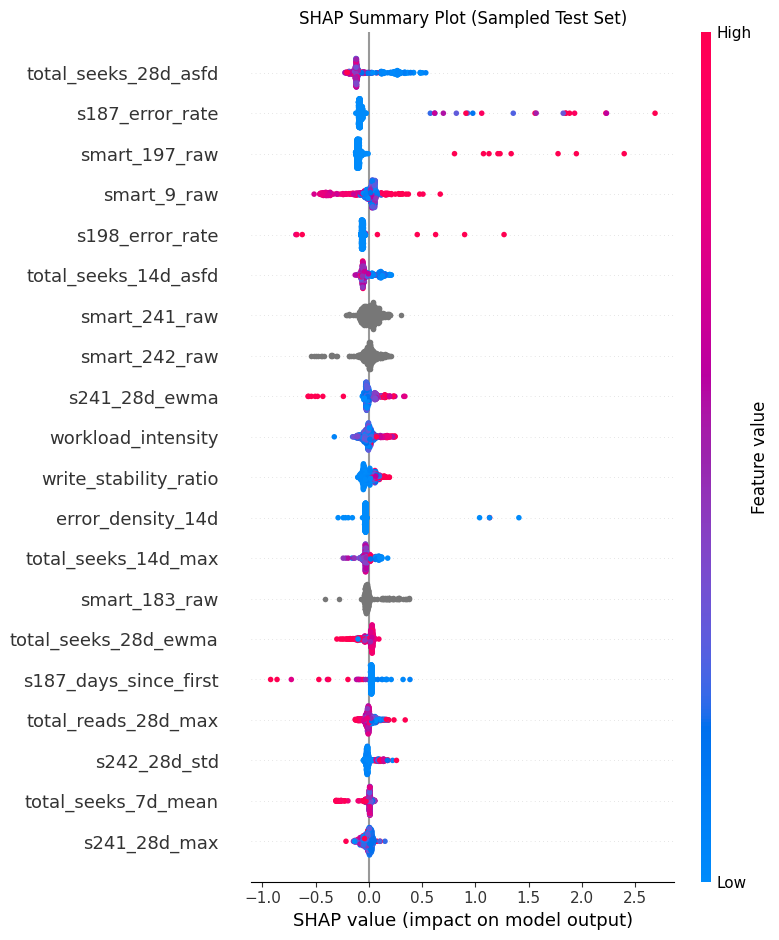

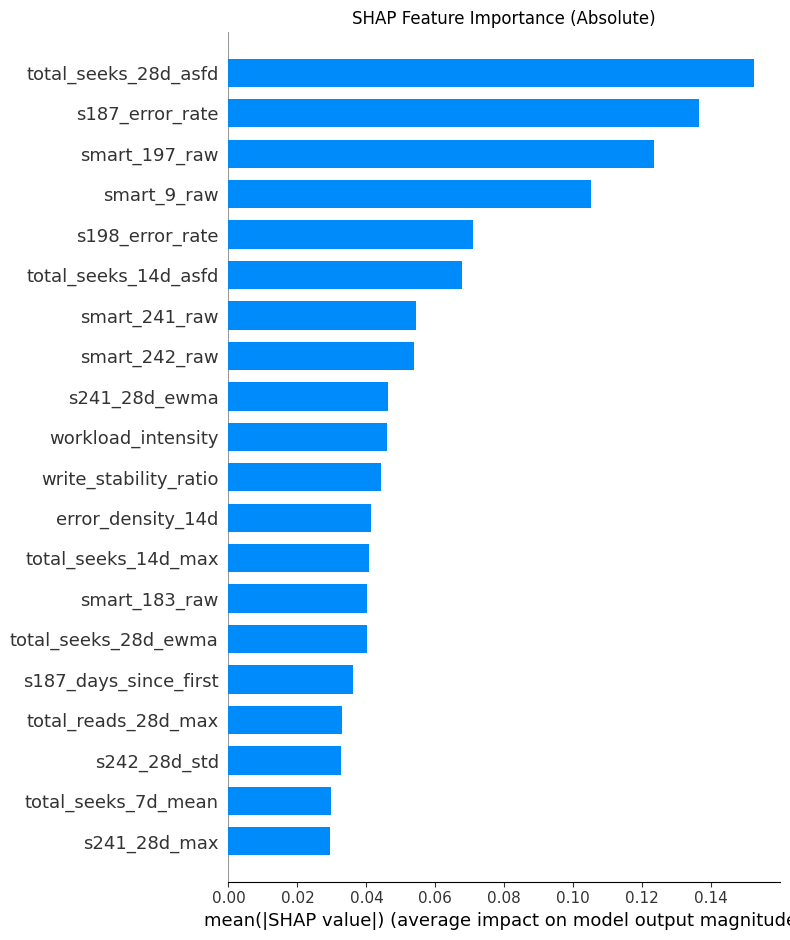

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
from tqdm.auto import tqdm
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap

# 0. 데이터 경로 설정
train_path = "../data/rfe_sample_data/rfe_sample_train.parquet"
test_path = "../data/rfe_sample_data/rfe_sample_test.parquet"

print("📦 데이터를 불러오는 중...")
train_df = duckdb.query(f"SELECT * FROM '{train_path}'").df()
test_df = duckdb.query(f"SELECT * FROM '{test_path}'").df()
print(f"✅ 데이터 로드 완료! (Train: {train_df.shape}, Test: {test_df.shape})")

# 1. GPU 인식 여부 확인
has_gpu = False
try:
    lgb.train({'device': 'gpu', 'verbose': -1}, lgb.Dataset(np.zeros((1, 1)), label=[0]))
    has_gpu = True
except:
    has_gpu = False
print(f"🖥️ 하드웨어 가속 상태: {'🚀 GPU (사용 가능)' if has_gpu else '💻 CPU (사용 가능)'}")

# 2. 학습/테스트 데이터 분리
X_train = train_df.drop(columns=['failure', 'date', 'serial_number'], errors='ignore')
y_train = train_df['failure']

X_test = test_df.drop(columns=['failure', 'date', 'serial_number'], errors='ignore')
y_test = test_df['failure']

# 3. 설정
model = LGBMClassifier(
    objective='binary',
    importance_type='gain', 
    # class_weight='balanced',
    scale_pos_weight=math.sqrt(10),
    max_depth=6,
    num_leaves=40, 
    n_estimators=200, 
    learning_rate=0.07, 
    device='gpu' if has_gpu else 'cpu',
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
importances_list = []

# 4. 5-Fold 교차 검증 (학습 데이터 기준)
for train_idx, val_idx in tqdm(list(cv.split(X_train, y_train)), desc="🚀 CV 진행률"):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model.fit(X_fold_train, y_fold_train)
    y_prob = model.predict_proba(X_fold_val)[:, 1]
    cv_scores.append(average_precision_score(y_fold_val, y_prob))
    importances_list.append(model.feature_importances_)

# 5. 테스트 데이터 평가 (최종 성능 확인)
model.fit(X_train, y_train) # 전체 학습 데이터로 다시 학습
test_prob = model.predict_proba(X_test)[:, 1]
test_score = average_precision_score(y_test, test_prob)

print(f"\n📊 [교차 검증] 평균 PR-AUC: {np.mean(cv_scores):.4f}")
print(f"🎯 [최종 테스트] PR-AUC: {test_score:.4f}")

# 6. 피처 중요도 정리
feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': np.mean(importances_list, axis=0)}).sort_values(by='importance', ascending=False)

print("\n🏆 상위 10개 피처:")
print(feat_imp.head(10).to_string(index=False))
print("\n📉 하위 10개 피처 (제거 후보):")
print(feat_imp.tail(10).to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
axes[0].set_title("🏆 Top 10 Features (Gain)")
sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
axes[1].set_title("📉 Bottom 10 Features")
plt.tight_layout()
plt.show()

# 7. SHAP 분석 (샘플링 적용)
# 테스트 데이터가 너무 크면 계산이 오래 걸리므로 500개만 무작위 추출합니다.
X_test_sample = X_test.sample(n=700, random_state=42)

print(f"\n🔮 SHAP 분석 진행 중... (샘플링된 {len(X_test_sample)}개 데이터 분석)")

# SHAP 계산 (TreeExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# LightGBM 이진 분류 대응 (Class 1: 고장 발생 선택)
if isinstance(shap_values, list):
    # shap_values가 리스트 형태인 경우 [정상_shap, 고장_shap] 중 1번 인덱스 사용
    sv = shap_values[1]
else:
    # 최신 shap 버전이나 모델 설정에 따라 단일 ndarray로 나올 수도 있음
    sv = shap_values

# 7-1. SHAP Summary Plot (피처별 영향력 분포)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Sampled Test Set)")
shap.summary_plot(sv, X_test_sample, max_display=20)

# 7-2. SHAP Bar Plot (피처별 평균 절대 영향력)
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Absolute)")
shap.summary_plot(sv, X_test_sample, plot_type="bar", max_display=20)



📦 데이터를 불러오는 중...
✅ 데이터 로드 완료! (Train: (298881, 87), Test: (688113, 87))
🖥️ 하드웨어 가속 상태: 🚀 GPU (사용 가능)


🚀 CV 진행률: 100%|██████████| 5/5 [00:08<00:00,  1.69s/it]



📊 [교차 검증] 평균 PR-AUC: 0.7171
🎯 [최종 테스트] PR-AUC: 0.3891

🏆 상위 20개 피처:
                  feature    importance
          s187_error_rate 385815.136733
reallocated_pending_ratio 155546.036098
        error_density_14d 142253.001355
     total_seeks_28d_asfd  59107.860703
    write_stability_ratio  37983.803011
             s184_28d_max  36168.283921
      total_seeks_28d_max  28791.149059
    s5_relative_score_14d  26804.808173
            s190_28d_mean  24251.962703
       io_asymmetry_index  23205.118289
            s241_28d_mean  19060.052257
     total_seeks_14d_mean  18887.760474
    s187_days_since_first  16045.465941
             s242_28d_sum  15003.587208
             s242_28d_max  14579.367506
             s194_7d_mean  13794.997139
             s241_28d_max  12505.514028
     s191_days_since_last  10791.372640
            s242_28d_asfd  10255.762873
             s242_28d_std   9905.708400

📉 하위 5개 피처 (제거 후보):
                      feature  importance
       shock_seek_interactio

C:\Users\joon6\AppData\Local\Temp\ipykernel_8356\3067107520.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
C:\Users\joon6\AppData\Local\Temp\ipykernel_8356\3067107520.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
C:\Users\joon6\AppData\Local\Temp\ipykernel_8356\3067107520.py:104: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\joon6\AppData\Local\Temp\ipykernel_8356\3067107520.py:104: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from fo

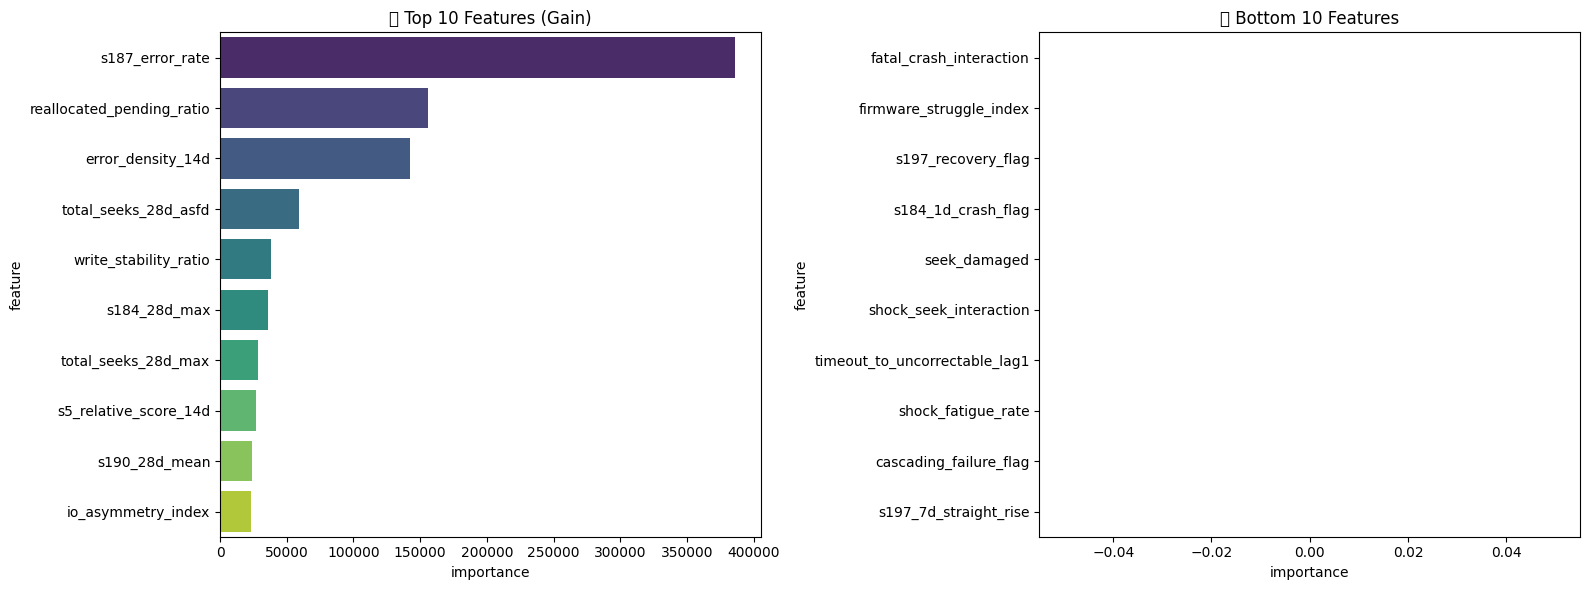

In [14]:
# s198_error_rate, s187_error_rate 없이 예측 

import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
import shap
from tqdm.auto import tqdm
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# 0. 데이터 경로 설정
train_path = "../data/rfe_sample_data/rfe_train.parquet"
test_path = "../data/rfe_sample_data/rfe_test.parquet"

print("📦 데이터를 불러오는 중...")
train_df = duckdb.query(f"SELECT * FROM '{train_path}'").df()
test_df = duckdb.query(f"SELECT * FROM '{test_path}'").df()
print(f"✅ 데이터 로드 완료! (Train: {train_df.shape}, Test: {test_df.shape})")

# 1. GPU 인식 여부 확인
has_gpu = False
try:
    lgb.train({'device': 'gpu', 'verbose': -1}, lgb.Dataset(np.zeros((1, 1)), label=[0]))
    has_gpu = True
except:
    has_gpu = False
print(f"🖥️ 하드웨어 가속 상태: {'🚀 GPU (사용 가능)' if has_gpu else '💻 CPU (사용 가능)'}")

# 2. 학습/테스트 데이터 분리
drop_cols = [
    'failure', 'date', 'serial_number', 
    's198_error_rate', 
    # 's187_error_rate',
    's198_damaged', 
    's187_damaged', 
    's5_damaged',
    # 's187_ever_flag', 
    # 's187_days_since_first',
    # 'error_density_14d',
    # 'reallocated_pending_ratio',
    # 's5_relative_score_14d',
    ]
X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['failure']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['failure']

# 3. 설정
model = LGBMClassifier(
    objective='binary',
    importance_type='gain', 
    class_weight='balanced',
    max_depth=6,
    num_leaves=40, 
    n_estimators=200, 
    learning_rate=0.07, 
    device='gpu' if has_gpu else 'cpu',
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
importances_list = []

# 4. 5-Fold 교차 검증 (학습 데이터 기준)
for train_idx, val_idx in tqdm(list(cv.split(X_train, y_train)), desc="🚀 CV 진행률"):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model.fit(X_fold_train, y_fold_train)
    y_prob = model.predict_proba(X_fold_val)[:, 1]
    cv_scores.append(average_precision_score(y_fold_val, y_prob))
    importances_list.append(model.feature_importances_)

# 5. 테스트 데이터 평가 (최종 성능 확인)
model.fit(X_train, y_train) # 전체 학습 데이터로 다시 학습
test_prob = model.predict_proba(X_test)[:, 1]
test_score = average_precision_score(y_test, test_prob)

print(f"\n📊 [교차 검증] 평균 PR-AUC: {np.mean(cv_scores):.4f}")
print(f"🎯 [최종 테스트] PR-AUC: {test_score:.4f}")

# 6. 피처 중요도 정리
feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': np.mean(importances_list, axis=0)}).sort_values(by='importance', ascending=False)

print("\n🏆 상위 20개 피처:")
print(feat_imp.head(20).to_string(index=False))
print("\n📉 하위 5개 피처 (제거 후보):")
print(feat_imp.tail(5).to_string(index=False))

# 시각화 (Feature Importance)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10), ax=axes[0], palette='viridis')
axes[0].set_title("🏆 Top 10 Features (Gain)")
sns.barplot(x='importance', y='feature', data=feat_imp.tail(10), ax=axes[1], palette='magma')
axes[1].set_title("📉 Bottom 10 Features")
plt.tight_layout()
plt.show()

# # 7. SHAP 분석
# print("\n🔮 SHAP 분석 진행 중... (테스트 데이터셋의 기여도 분석)")
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)

# if isinstance(shap_values, list):
#     sv = shap_values[1]
# else:
#     sv = shap_values

# plt.figure(figsize=(10, 8))
# plt.title("SHAP Summary Plot (Test Set)")
# shap.summary_plot(sv, X_test, max_display=20)

# plt.figure(figsize=(10, 8))
# plt.title("SHAP Feature Importance (Absolute)")
# shap.summary_plot(sv, X_test, plot_type="bar", max_display=20)
